# Simple Deep Learning On Male Data - ASVspoof2019 Dataset:

In [1]:
import sys
sys.path.append('../')
import scipy.io as sio
import mat73
import pandas as pd
import torch
import numpy as np
import torch.optim as optim
import torch.nn
import sklearn
import sklearn.metrics
import matplotlib.pyplot as plt
from alive_progress import alive_bar
from  utils.my_classes import dataset 
from torch.utils.data import DataLoader
import utils.DNN_functions as DNN_functions
import scipy
import random
import utils.AMSloss
seed = 5  # You can choose any integer value as the seed
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
# Set seed for Python's random module
random.seed(seed)
# Set seed for NumPy
np.random.seed(seed)
# Set seed for PyTorch (CPU and GPU, if available)
if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
# Set deterministic flags for PyTorch (if available)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

c:\Users\avish\OneDrive\Desktop\thesis_research\avishai_work\env\lib\site-packages\scipy\__init__.py:177: UserWarning: A NumPy version >=1.18.5 and <1.26.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
#To get my GPU device - GTX 4070 :)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu');

if torch.cuda.is_available():
    print(torch.cuda.device_count())
    print(torch.cuda.device(0))
    print(torch.cuda.get_device_name(0))
    print(device)

1
NVIDIA GeForce RTX 4070
cuda


In [3]:
from ASV_utils.data_loading import *


data_path_male = "Data/pmf_both/not_normalize/male/"


embedded_groups_1_1,embedded_groups_1_2,embedded_groups_1_3,chosen_labels_1_1_is_spoofed,chosen_labels_2_1_is_spoofed,chosen_labels_3_1_is_spoofed,chosen_labels_numeric_1_1,chosen_labels_numeric_2_1,chosen_labels_numeric_3_1,chosen_labels_1_1_attack_logical,chosen_labels_2_1_attack_logical,chosen_labels_3_1_attack_logical,chosen_labels_1_1_name,chosen_labels_2_1_name,chosen_labels_3_1_name,chosen_labels_1_1_speaker_id,chosen_labels_2_1_speaker_id,chosen_labels_3_1_speaker_id,male_chosen_labels_1_1_sex,male_chosen_labels_2_1_sex,male_chosen_labels_3_1_sex  = load_data_male(data_path_male)



## Preprocessing channels

Here, I will perform preprocessing and rearrange the channel order before feeding it into the Deep Neural Network (DNN).

In [4]:
#order by this example:
#filter-gammatone-channel-1-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]',
#       'filter-gammatone-channel-1-distance-Correlation-[d_(p,p_s)-d(p,p_h)]',
#       'filter-gammatone-channel-1-distance-Hellinger-[d_(p,p_s)-d(p,p_h)]',
#       'filter-gammatone-channel-1-distance-Intersection-[d_(p,p_s)-d(p,p_h)]',
#       'filter-gammatone-channel-1-distance-Jensen-Shannon-[d_(p,p_s)-d(p,p_h)

# get the real channel by the order of the features

import utils.my_functions as my_functions
columns_names,max_name_length = my_functions.get_columns_names_feature_importance(substruct=True)
true_channels_indexes = np.array(my_functions.get_real_channel(np.linspace(start=1, stop=len(columns_names), num=len(columns_names)),len(columns_names)))
true_channels_indexes = true_channels_indexes - 1
true_channels_indexes = true_channels_indexes.astype(int)
columns_names = np.array(columns_names)
embedded_groups_1_1 = embedded_groups_1_1[:,true_channels_indexes]
embedded_groups_1_2 = embedded_groups_1_2[:,true_channels_indexes]
embedded_groups_1_3 = embedded_groups_1_3[:,true_channels_indexes]

In [5]:
# order by metric type and then by channel number and then by gammatone and gammatone_inv, example:
#filter-gammatone-channel-1-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]
#filter-gammatone-channel-2-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]
#filter-gammatone-channel-3-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]
#filter-gammatone-channel-4-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]
#filter-gammatone-channel-5-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]
#filter-gammatone-channel-6-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]
#filter-gammatone-channel-7-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]
#filter-gammatone-channel-8-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]
#filter-gammatone-channel-9-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]
#filter-gammatone-channel-10-distance-Chi-square-[d_(p,p_s)-d(p,p_h)]
#filter-gammatone-channel-1-distance-Correlation-[d_(p,p_s)-d(p,p_h)]
#filter-gammatone-channel-2-distance-Correlation-[d_(p,p_s)-d(p,p_h)]
import re


your_list = columns_names[true_channels_indexes]
index_mapping ={}

# Define the custom sorting order for distance metrics
distance_metrics = [
    'Chi-square',
    'Correlation',
    'Hellinger',
    'Intersection',
    'Jensen-Shannon',
    'Kullback-Leibler Divergence',
    'Modified Kolmogorov-Smirnov',
    'Symmetrised Kullback-Leibler'
]

def custom_sort_key(item):
    # Use regex to extract filter type, channel number, and distance metric
    match = re.search(r'filter-(gammatone|gammtone_inv)-channel-(\d+)-distance-(.+?)-\[d_', item)
    if match:
        filter_type = match.group(1)  # 'gammatone' or 'gammtone_inv'
        channel = int(match.group(2))
        distance_metric = match.group(3)
        
        # Prioritize 'gammatone' before 'gammtone_inv'
        filter_priority = 0 if filter_type == 'gammatone' else 1

        # Sort by filter type, then by distance metric, and finally by channel
        return (filter_priority, distance_metrics.index(distance_metric), channel)

    else:
        # If the regex doesn't match, push the item to the end
        return (999, 999, 999)

# Sort the list based on the custom order
sorted_list = sorted(your_list, key=custom_sort_key)

for new_index, item in enumerate(sorted_list):
    old_index = np.where(columns_names[true_channels_indexes] == item)[0][0]
    index_mapping[old_index] = new_index
    
embedded_groups_1_1 = embedded_groups_1_1[:,list(index_mapping.keys())]
embedded_groups_1_2 = embedded_groups_1_2[:,list(index_mapping.keys())]
embedded_groups_1_3 = embedded_groups_1_3[:,list(index_mapping.keys())]

In [6]:
from dataclasses import dataclass
import torch
from torch.utils.data import Dataset
@dataclass
class dataset2(Dataset):
    data : np.ndarray 
    is_spoofed : pd.core.series.Series 
    chosen_labels_numeric : pd.core.series.Series
    attack_logical : pd.core.series.Series
    name : pd.core.series.Series
    speaker_id :  pd.core.series.Series
    data_transform : torch.Tensor = None
    labels_transform : torch.Tensor = None
    sex : pd.core.series.Series = None
    labels_format : str = 'is_spoofed' #['is_spoofed', 'one-hot','is_not_spoofed']
    data_for_gender_classification : np.ndarray = None
    data_without_separation  : np.ndarray = None
    
    def __len__(self):
        labels = self.is_spoofed
        return len(labels)
    
    def len_is_spoofed(self):
        return(self.is_spoofed.value_counts())
    
    def __getitem__(self, idx):
        data_sample = self.data[idx,:]  
        attack_sample = self.attack_logical.iloc[idx] # attack logical
        label_sample = (self.is_spoofed.iloc[idx].astype('uint8')).astype('float32') # is spoofed
        
        if self.labels_format == 'one-hot':
            label_sample = np.array([0,1] if label_sample == 0 else [1,0]) #one hot encoding
            
        if self.labels_format == 'is_not_spoofed':
            label_sample = np.array(1 if label_sample == 0 else 0) #convert 0 to 1 and 1 to 0 - is not spoofed
        
        if self.data_transform:
            data_sample = self.transform(data_sample)
        if self.labels_transform:
            label_sample = self.transform(label_sample)
        return data_sample,attack_sample,label_sample 
    
    def set_labels_format(self, labels_format):
        if labels_format not in ['is_spoofed', 'one-hot','is_not_spoofed']:
            raise ValueError("labels_format must be 'is_spoofed' or 'one-hot' or 'is_not_spoofed' .")
        self.labels_format = labels_format
    
    def shuffle(self,res = None):
        if res is None: # if we dont reasampling to the data and labels
            idx = np.random.permutation(len(self))
            self.data = self.data[idx,:]
            self.is_spoofed = self.is_spoofed.loc[idx]
            self.is_spoofed = self.is_spoofed.reset_index(drop=True)
            self.chosen_labels_numeric = self.chosen_labels_numeric.loc[idx]
            self.chosen_labels_numeric = self.chosen_labels_numeric.reset_index(drop=True)
            self.attack_logical = self.attack_logical.loc[idx]
            self.attack_logical = self.attack_logical.reset_index(drop=True)
            self.name = self.name.loc[idx]
            self.name = self.name.reset_index(drop=True)
            self.speaker_id = self.speaker_id.loc[idx]
            self.speaker_id = self.speaker_id.reset_index(drop=True)
            self.sex = self.sex.loc[idx]
            self.sex = self.sex.reset_index(drop=True)
            return self
        else: # if we do reasampling to the data and labels
            idx = np.random.permutation(len(self))
            self.data = self.data[idx,:]
            self.is_spoofed = self.is_spoofed.loc[idx]
            return self
        
        
        

In [7]:
#create the datasets
train_dataset = dataset(data = embedded_groups_1_1 , is_spoofed = chosen_labels_1_1_is_spoofed , chosen_labels_numeric = chosen_labels_numeric_1_1,
                        attack_logical = chosen_labels_1_1_attack_logical, name = chosen_labels_1_1_name , speaker_id = chosen_labels_1_1_speaker_id,sex = male_chosen_labels_1_1_sex, data_transform = None , labels_transform = None);

validation_dataset = dataset2(data = embedded_groups_1_2 , is_spoofed = chosen_labels_2_1_is_spoofed , chosen_labels_numeric = chosen_labels_numeric_2_1,
                        attack_logical = chosen_labels_2_1_attack_logical, name = chosen_labels_2_1_name , speaker_id = chosen_labels_2_1_speaker_id, sex = male_chosen_labels_2_1_sex ,data_transform = None , labels_transform = None);


test_dataset = dataset2(data = embedded_groups_1_3 , is_spoofed = chosen_labels_3_1_is_spoofed , chosen_labels_numeric = chosen_labels_numeric_3_1,
                        attack_logical = chosen_labels_3_1_attack_logical, name = chosen_labels_3_1_name , speaker_id = chosen_labels_3_1_speaker_id, sex = male_chosen_labels_3_1_sex ,data_transform = None , labels_transform = None);

In [8]:
train_dataset.attack_logical = pd.Series([elem[0] for elem in train_dataset.attack_logical.values])

validation_dataset.attack_logical = pd.Series([elem[0] for elem in validation_dataset.attack_logical.values])

test_dataset.attack_logical = pd.Series([elem[0] for elem in test_dataset.attack_logical.values])

In [9]:
# normalize the train, validation and test datasets
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler(with_mean = True, with_std = True)
scaler.fit(train_dataset.data)
mean_features = scaler.mean_
std_features = scaler.scale_
train_dataset.data = scaler.transform(train_dataset.data)
validation_dataset.data = scaler.transform(validation_dataset.data)
test_dataset.data = scaler.transform(test_dataset.data)

In [10]:
# balanced the data with SVM SMOTE
import imblearn.over_sampling as over_sampling

sm = over_sampling.SVMSMOTE(sampling_strategy='minority', random_state=seed,k_neighbors=5)
train_dataset.data , train_dataset.is_spoofed  = sm.fit_resample(X = train_dataset.data , y = train_dataset.is_spoofed) # just on the train set

In [11]:
#check if the data now is balanced
print(f"|| train dataset length - {len(train_dataset)} ||");
print(f"|| train dataset - len_is_spoofed ? \nlength - \n{train_dataset.len_is_spoofed()} ||");
print(f"|| validation dataset length - {len(validation_dataset)} ||");
print(f"|| validation dataset - len_is_spoofed ? \nlength - \n{validation_dataset.len_is_spoofed()} ||");
print(f"|| test dataset length - {len(test_dataset)} ||");
print(f"|| test dataset - len_is_spoofed ? \nlength - \n{test_dataset.len_is_spoofed()} ||");

|| train dataset length - 18816 ||
|| train dataset - len_is_spoofed ? 
length - 
0    9408
1    9408
Name: count, dtype: int64 ||
|| validation dataset length - 8260 ||
|| validation dataset - len_is_spoofed ? 
length - 
1    7392
0     868
Name: count, dtype: int64 ||
|| test dataset length - 21939 ||
|| test dataset - len_is_spoofed ? 
length - 
1    19656
0     2283
Name: count, dtype: int64 ||


In [12]:
# define the labels types
train_dataset.set_labels_format('is_spoofed')
validation_dataset.set_labels_format('is_spoofed')
test_dataset.set_labels_format('is_spoofed')

In [13]:
# define the dataloaders
train_dataloader = DataLoader(train_dataset, batch_size=256, shuffle=True);
validation_dataloader = DataLoader(validation_dataset, batch_size=256, shuffle=True);
test_dataloader = DataLoader(test_dataset, batch_size=256, shuffle=True);

print(f"|| train dataloader length - {len(train_dataloader)} ||");
print(f"|| validation dataloader length - {len(validation_dataloader)} ||");
print(f"|| test dataloader length - {len(test_dataloader)} ||");

|| train dataloader length - 74 ||
|| validation dataloader length - 33 ||
|| test dataloader length - 86 ||


## Deep Neural Network

Here I define the netwok and training the model.

In [14]:

# define the subchannel model network
import torch.nn as nn
class SubChannelNetwork(nn.Module):
    def __init__(self, input_channel_size, output_channel_size):
        super(SubChannelNetwork, self).__init__()
        self.input_layer = nn.Linear(input_channel_size, output_channel_size)
        self.sigmoid = nn.Sigmoid()
        self.dropout = nn.Dropout(p=0.2)
        self.BN_4 = nn.BatchNorm1d(output_channel_size) 

        
    def forward(self, x):
        x = self.input_layer(x)
        x = self.BN_4(x) 
        x = self.sigmoid(x)
        x = self.dropout(x)
        return x

In [15]:
import torch
import torch.nn as nn
from utils.AMSloss import AdMSoftmaxLoss

# define the model network
class DNN(nn.Module):
    def __init__(self, input_channel_size, num_subnetworks, output_channel_size, final_output_size):
        super(DNN, self).__init__()
        self.SubChannelNetwork = nn.ModuleList([
            SubChannelNetwork(input_channel_size, output_channel_size) for _ in range(num_subnetworks)
        ])
        self.fc_between_subnet = nn.Linear(num_subnetworks * output_channel_size,40)
        self.BN = nn.BatchNorm1d(40)
        self.fc = nn.Linear(40, final_output_size)
        self.sigmoid = nn.Sigmoid()
        self.droupout = nn.Dropout(p=0.2)
        self.loss = nn.BCEWithLogitsLoss()
        self.optimizer = None
        self.scheduler = None
        
        
    def forward(self, x):
        subnetwork_outputs = [self.SubChannelNetwork[idx](x[:, idx*input_channel_size:(idx+1)*input_channel_size].to(device)) for idx in range(len(self.SubChannelNetwork))]
        combined_output = torch.cat(subnetwork_outputs, dim=1)
        x = self.fc_between_subnet(combined_output)    
        x = self.BN(x)
        x = self.sigmoid(x)
        x = self.droupout(x)
        output = self.fc(x)
        return output 
    
    @staticmethod
    def count_parameters(model):
        return sum(p.numel() for p in model.parameters() if p.requires_grad)



# Just for checking the model and see the number of parameters
num_SubChannelNetwork = 16
input_channel_size = 10
output_channel_size = 5
final_output_size = 1
model = []
model = DNN(input_channel_size, num_SubChannelNetwork, output_channel_size, final_output_size)
model = model.to(device)
print(model)
n = DNN.count_parameters(model)
print("Number of parameters: %s" % n)

DNN(
  (SubChannelNetwork): ModuleList(
    (0-15): 16 x SubChannelNetwork(
      (input_layer): Linear(in_features=10, out_features=5, bias=True)
      (sigmoid): Sigmoid()
      (dropout): Dropout(p=0.2, inplace=False)
      (BN_4): BatchNorm1d(5, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (fc_between_subnet): Linear(in_features=80, out_features=40, bias=True)
  (BN): BatchNorm1d(40, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc): Linear(in_features=40, out_features=1, bias=True)
  (sigmoid): Sigmoid()
  (droupout): Dropout(p=0.2, inplace=False)
  (loss): BCEWithLogitsLoss()
)
Number of parameters: 4401


In [16]:
def test_attacks_cm(cm_score,attack_type,cm_label):
    cm_score = np.concatenate(cm_score)
    attack_type = np.concatenate(attack_type)
    cm_label = np.concatenate(cm_label)
    eer_cm_lst = []
    for attack_idx in range(9,20):
       
        # Extract bona fide (real human) and spoof scores from the CM scores
        
        indexes_bona = np.where(cm_label == 0)
        indexes_attacks = np.where(attack_type == 'A%02d' % attack_idx)
        
        cm_scores_temp = np.concatenate((cm_score[indexes_bona], cm_score[indexes_attacks]))
        
        cm_labels_temp = np.concatenate((cm_label[indexes_bona], cm_label[indexes_attacks]))
        
        eer_cm = my_functions.compute_eer(cm_labels_temp, cm_scores_temp)[0]
        eer_cm_lst.append(eer_cm)
    
    return eer_cm_lst


In [17]:
#one threshold_eer for all the attacks
# def test_attacks_cm_miss_classification(cm_score, attack_type, cm_label):
#     # Concatenate inputs to ensure they are single continuous arrays
#     cm_score = np.concatenate(cm_score)
#     attack_type = np.concatenate(attack_type)
#     cm_label = np.concatenate(cm_label)
    
#     overall_eer,threshold_eer = my_functions.compute_eer(cm_label, cm_score)
    
#     misclassification_percentage = []
#     # Compute EER and percentage of misclassified attacks for each attack type
#     percentage_misclassified = []
#     for attack_idx in range(9, 20):
#         attack_type_str = f'A{attack_idx:02d}'
#         attack_indexes = np.where(attack_type == attack_type_str)[0]
#         attack_scores = cm_score[attack_indexes]
#         attack_labels = cm_label[attack_indexes]
        
#         # Calculate EER for the current attack type
#         total_attacks = len(attack_labels)
#         num_misclassified = sum(attack_scores <= threshold_eer)
#         percentage_misclassified.append((num_misclassified / total_attacks))
     
#     misclassification_percentage.append(percentage_misclassified)
    
#     return misclassification_percentage

In [18]:
# #different threshold eer for each attack
def test_attacks_cm_miss_classification(cm_score, attack_type, cm_label):
    # Concatenate inputs to ensure they are single continuous arrays
    cm_score = np.concatenate(cm_score)
    attack_type = np.concatenate(attack_type)
    cm_label = np.concatenate(cm_label)
    
    
    
    # Compute EER and misclassification percentage for each attack type
    eer_per_attack = []
    misclassification_percentage = []
    
    for attack_idx in range(7, 20):
        attack_type_str = f'A{attack_idx:02d}'
        attack_indexes = np.where(attack_type == attack_type_str)[0]
        attack_scores = cm_score[attack_indexes]
        attack_labels = cm_label[attack_indexes]
        indexes_bona = np.where(cm_label == 0)
        bonafide_scores = cm_score[indexes_bona]
        bondafide_labels = cm_label[indexes_bona]
        # Calculate EER for the current attack type
        scores = np.concatenate((attack_scores, bonafide_scores))
        labels = np.concatenate((attack_labels, bondafide_labels))
        _,_,eer_with_attack, threshold_eer = my_functions.compute_eer_2(labels, scores)
        eer_with_attack = 100*eer_with_attack
        eer_per_attack.append(eer_with_attack)
        
        # Calculate the number of misclassified attacks based on the threshold
        num_misclassified = sum(attack_scores <= threshold_eer)
        total_attacks = len(attack_labels)
        percentage_misclassified = (num_misclassified / total_attacks) * 100
        misclassification_percentage.append(percentage_misclassified)
    
    return eer_per_attack


In [19]:
# #different threshold eer for each attack
def val_attacks_cm_miss_classification(cm_score, attack_type, cm_label):
    # Concatenate inputs to ensure they are single continuous arrays
    cm_score = np.concatenate(cm_score)
    attack_type = np.concatenate(attack_type)
    cm_label = np.concatenate(cm_label)
    
    
    
    # Compute EER and misclassification percentage for each attack type
    eer_per_attack = []
    misclassification_percentage = []
    
    for attack_idx in range(1, 7):
        attack_type_str = f'A{attack_idx:02d}'
        attack_indexes = np.where(attack_type == attack_type_str)[0]
        attack_scores = cm_score[attack_indexes]
        attack_labels = cm_label[attack_indexes]
        indexes_bona = np.where(cm_label == 0)
        bonafide_scores = cm_score[indexes_bona]
        bondafide_labels = cm_label[indexes_bona]
        # Calculate EER for the current attack type
        scores = np.concatenate((attack_scores, bonafide_scores))
        labels = np.concatenate((attack_labels, bondafide_labels))
        _,_,eer_with_attack, threshold_eer = my_functions.compute_eer_2(labels, scores)
        eer_with_attack = 100*eer_with_attack
        eer_per_attack.append(eer_with_attack)
        
        # Calculate the number of misclassified attacks based on the threshold
        num_misclassified = sum(attack_scores <= threshold_eer)
        total_attacks = len(attack_labels)
        percentage_misclassified = (num_misclassified / total_attacks) * 100
        misclassification_percentage.append(percentage_misclassified)
    
    return eer_per_attack

In [20]:
# Train the model with 1 neuruon in the last layer with sigmoid activation function in the last layer
from utils.pytorchtools import EarlyStopping
import torch.nn.functional as F 
import mlflow
import pickle
def train_model_new(training_type,model,train_dataloader,validation_dataloader ,eval_dataloader,num_epoch,checkpoint_path=None,patience = None):
    '''
    Args:
        training_type: '1_neorun_end_sigmoid' or '2_neorun_end_softmax' or '2_neorun_end_AMS' or '2_neorun_end_OCS'
        model: model to train
        train_dataloader: train dataloader
        validation_dataloader: validation dataloader
        num_epoch: number of epochs
        checkpoint_path: path to save the model
        patience: patience for early stopping
    Returns:
        model: trained model
        train_losses_total: all the train loss
        validation_losses_total: all the validation loss
        train_balanced_acc_total: all the train balanced accuracy
        valid_balanced_acc_total: all the validation balanced accuracy
        f1_score_validation_total: all the validation f1 score
        validation_total_eer: all the validation eer
        train_total_eer: all the train eer
    '''
    # check if training_type is valid
    if training_type != "1_neorun_end_sigmoid" and training_type != "2_neorun_end_softmax" and training_type != "2_neorun_end_AMS" and training_type != "2_neorun_end_OCS":
        raise ValueError("training_type must be '1_neorun_end_sigmoid' or '2_neorun_end_softmax' or '2_neorun_end_AMS' or '2_neorun_end_OCS'")
    
    utils.DNN_functions.set_random_seeds(seed=42)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu');
    
    if training_type == "2_neorun_end_AMS":
        embedding_dim = model.loss.embedding_dim # embedding dimension for AMS
    elif training_type == "2_neorun_end_OCS":
        embedding_dim = model.loss.feat_dim # embedding dimension for OCS
    else:
        embedding_dim = None # embedding dimension for sigmoid and softmax

    if patience is None:
        patience = num_epoch  
        
    criterion = model.loss # loss function    

    optimizer = model.optimizer # optimizer
        
    scheduler = model.scheduler
    
    
    # initialize the early_stopping object
    early_stopping = EarlyStopping(patience=patience, verbose=True,onnx=False)

    if checkpoint_path is not None:
        early_stopping = EarlyStopping(patience=patience, verbose=False,path=checkpoint_path,onnx=False)

    train_losses_total = []; train_balanced_acc_total = []; validation_losses_total = []; valid_balanced_acc_total = []; f1_score_validation_total = [];
    
    validation_total_eer = []; train_total_eer = [];
    
    all_eval_list = []; all_val_list = []
    
    train_norm_all_outputs = None
    
    validation_norm_all_outputs = None

    with alive_bar(total=num_epoch) as pbar:
        model.train()
        if training_type == "2_neorun_end_AMS" or training_type == "2_neorun_end_OCS": 
            criterion.train()
        for epoch in range(1, num_epoch+1 ):
            pbar(skipped=True)
            loss_epoch = [] # loss per epoch
            train_total_labels_epoch = [] # all the labels per epoch
            train_total_score_epoch = []   # all the score per epoch
            if training_type == "2_neorun_end_AMS" or training_type == "2_neorun_end_OCS":
                train_norm_all_outputs = np.zeros((1,embedding_dim)) # all the outputs per epoch

            for _ , (data_iter, labels_iter) in enumerate(train_dataloader):
                optimizer.zero_grad()# Initializes the weights
                data_iter = data_iter.to(device) # send data to device
                labels_iter = labels_iter.to(device).type(torch.LongTensor) # send labels to device
                output = model(data_iter.float()); # forward propagation
                output = output.to(device).type(torch.Tensor) # send output to device
                
                if training_type == "1_neorun_end_sigmoid":
                    labels_iter = labels_iter.float() # convert labels to float
                    loss = criterion(torch.squeeze(output).to(device), labels_iter.to(device))
                    loss.backward() #Back_propagation
                    optimizer.step() #Updating the optimizer
                    score = torch.sigmoid(output).squeeze()  #Apply sigmoid to the output
               
                if training_type == "2_neorun_end_softmax":
                    loss = criterion(output.to(device), labels_iter.to(device))
                    loss.backward() #Back_propagation
                    optimizer.step() #Updating the optimizer
                    score = torch.softmax(output,dim = 1).squeeze()  #Apply softmax to the output
            
                if training_type == "2_neorun_end_AMS":
                    loss, _ ,logits = criterion(output.to(device), labels_iter.to(device))  #Calculate the loss
                    loss.backward() #Back_propagation
                    optimizer.step() #Updating the optimizer
                    train_norm_output  = F.normalize(output)
                    score = torch.softmax(logits,dim = 1).squeeze()  #Apply softmax to the output
                
                if training_type == "2_neorun_end_OCS":
                    loss, score = criterion(output.to(device), labels_iter.to(device))
                    score = -1*score #because the probability of the positive class is when the score is bigger than thrheshold

                    loss.backward() #Back_propagation
                    optimizer.step() #Updating the optimizer
                    train_norm_output  = F.normalize(output)
                    
                
                labels_iter = labels_iter.squeeze() # squeeze labels
                
                loss_epoch.append(loss.item()) # loss per batch
                
                train_total_score_epoch.append(score.cpu().detach().numpy()) # all the score per epoch
                train_total_labels_epoch.append(labels_iter.cpu().detach().numpy()) # all the labels per epoch
                
                #print(f"Train Epoch: {epoch} [{batch_idx * len(data_iter)}/{len(train_dataloader.dataset)}] ,Train Loss: {loss.item():.5f}") # print loss per batch
           

                if training_type == "2_neorun_end_AMS" or  training_type == "2_neorun_end_OCS":
                    train_norm_all_outputs = np.vstack((train_norm_all_outputs, train_norm_output.detach().numpy()))
            
            train_total_score_epoch = np.concatenate(train_total_score_epoch) # concatenate all the score per epoch
            train_total_labels_epoch = np.concatenate(train_total_labels_epoch) # concatenate all the labels per epoch
            
            if training_type == "2_neorun_end_softmax" or training_type == "2_neorun_end_AMS": 
                    train_total_score_epoch = train_total_score_epoch[:,1]
          
            eer, thresh = my_functions.compute_eer(train_total_labels_epoch,train_total_score_epoch) # compute equal error rate
           
            train_total_eer.append(eer) # all the train eer
            
            prediction_epoch = np.array([1 if total_score_element > thresh else 0 for total_score_element in train_total_score_epoch]) # prediction for specific threshold
 
            train_balanced_acc_total.append(sklearn.metrics.balanced_accuracy_score(train_total_labels_epoch,prediction_epoch)) ## total acurrecy 
                
                
            train_acc_percentage_epoch = (100. * train_balanced_acc_total[epoch-1]); # train balanced accuracy per epoch in percentage
            
            print(f"\nTrain Balanced Accuracy:  {train_acc_percentage_epoch:.2f}%")
            print(f"Train EER:  {100*eer:.2f}%\n")
            
        
            train_losses_total.append(np.average(loss_epoch)) # all the train loss 
            if scheduler is not None:
                scheduler.step() # update learning rate

            if eval_dataloader is not None: # if eval dataloader is not None then do evaluation after each epoch
                eval_total_score_epoch = [] # all the score per epoch
                eval_total_labels_epoch = [] # all the labels per epoch
                eval_total_attack_epoch = [] # all the attack per epoch
                model.eval()
                criterion.eval()
              
                with torch.no_grad():
                    for _, (data_iter_eval,attack_iter_eval, labels_iter_eval) in enumerate(eval_dataloader):
                        data_iter_eval = data_iter_eval.to(device) # send data to device
                        labels_iter_eval = labels_iter_eval.to(device).type(torch.LongTensor) # send labels to device
                        output = model((data_iter_eval).float()) # forward propagation
                        output = output.to(device).type(torch.Tensor) # send output to device
                        if training_type == '1_neorun_end_sigmoid':
                            # loss = criterion(torch.squeeze(output).to(device), labels_iter_eval.to(device))
                            score = torch.sigmoid(output) #because the probability of the positive class is when the score is bigger than threshold
                        eval_total_score_epoch.append(score.cpu().detach().numpy()) # all the score per epoch
                        eval_total_labels_epoch.append(labels_iter_eval.cpu().detach().numpy()) # all the labels per epoch
                        eval_total_attack_epoch.append(np.array(attack_iter_eval)) # all the attack per epoch
                    eer_eval_list = test_attacks_cm_miss_classification(eval_total_score_epoch,eval_total_attack_epoch,eval_total_labels_epoch)
                    all_eval_list.append(eer_eval_list)
                    
                
               

            if validation_dataloader is not None: # if validation dataloader is not None then do validation after each epoch
                model.eval()
                if training_type == "2_neorun_end_AMS" or training_type == "2_neorun_end_OCS": 
                    criterion.eval()
                
                val_loss_epoch = []  # loss per epoch
                validation_losses_epoch = [] # average validation loss per epoch
                    
                valid_balanced_acc_epoch = [] # balanced accuracy per epoch
            
                valid_f1_score_epoch = [] # f1 score per epoch
                
                validation_total_labels_epoch = [] # all the labels per epoch
                validation_total_score_epoch = []  # all the score per epoch
                
                if training_type == "2_neorun_end_AMS" or training_type == "2_neorun_end_OCS":
                    validation_norm_all_outputs = np.zeros((1,embedding_dim)) # all the outputs per epoch
                
                
                val_total_score_epoch = [] # all the score per epoch
                val_total_labels_epoch = [] # all the labels per epoch
                val_total_attack_epoch = [] # all the attack per epoch
                
                with torch.no_grad():
                    for _, (data_iter_val,attack_iter_val, labels_iter_val) in enumerate(validation_dataloader):
                        data_iter_eval = data_iter_val.to(device) # send data to device
                        labels_iter_eval = labels_iter_val.to(device).type(torch.LongTensor) # send labels to device
                        output = model((data_iter_val).float()) # forward propagation
                        output = output.to(device).type(torch.Tensor) # send output to device
                        if training_type == '1_neorun_end_sigmoid':
                            # loss = criterion(torch.squeeze(output).to(device), labels_iter_eval.to(device))
                            score = torch.sigmoid(output) #because the probability of the positive class is when the score is bigger than threshold
                        val_total_score_epoch.append(score.cpu().detach().numpy()) # all the score per epoch
                        val_total_labels_epoch.append(labels_iter_val.cpu().detach().numpy()) # all the labels per epoch
                        val_total_attack_epoch.append(np.array(attack_iter_val)) # all the attack per epoch
                    eer_val_list = val_attacks_cm_miss_classification(val_total_score_epoch,val_total_attack_epoch,val_total_labels_epoch)
                    all_val_list.append(eer_val_list)
                
                
                
                    
                with torch.no_grad():
                    for _, (data_iter_val,attack_iter_val, labels_iter_val) in enumerate(validation_dataloader):
                        data_iter_val = data_iter_val.to(device) # send data to device
                        labels_iter_val = labels_iter_val.to(device).type(torch.LongTensor) # send labels to device
                        output = model((data_iter_val).float()) # forward propagation
                        output = output.to(device).type(torch.Tensor) # send output to device
                        if training_type == "1_neorun_end_sigmoid":
                            labels_iter_val = labels_iter_val.float()
                            loss = criterion(torch.squeeze(output).to(device),labels_iter_val.to(device))  #Calculate the loss
                            score = torch.sigmoid(output)  #Apply sigmoid to the output
                        
                        if training_type == "2_neorun_end_softmax":
                            loss = criterion(output.to(device),labels_iter_val.to(device))  #Calculate the loss
                            score = torch.softmax(output,dim = 1)  #Apply softmax to the output
                        
                        if training_type == "2_neorun_end_AMS":
                            loss, _ ,logits = criterion(output.to(device), labels_iter_val.to(device))  #Calculate the loss
                            validation_norm_output  = F.normalize(output)
                            score = torch.softmax(logits,dim = 1).squeeze()  #Apply softmax to the output
                        
                        if training_type == "2_neorun_end_OCS":
                            loss, score = criterion(output.to(device), labels_iter_val.to(device))
                            score = -1*score #because the probability of the positive class is when the score is bigger than threshold
                            validation_norm_output  = F.normalize(output)
                            
                            
                        if torch.cuda.is_available():
                            loss = loss.cpu() # send loss to cpu
                            val_loss_epoch.append(loss.item()) # loss per batch

                            
                            validation_total_score_epoch.append(score.cpu().detach().numpy()) # all the score per epoch
                            
                            validation_total_labels_epoch.append(labels_iter_val.cpu().detach().numpy()) # all the labels per epoch
                            
                            if training_type == "2_neorun_end_AMS" or training_type == "2_neorun_end_OCS":
                                validation_norm_all_outputs = np.vstack((validation_norm_all_outputs, validation_norm_output)) # all the outputs per epoch

                        
                    validation_total_score_epoch = np.concatenate(validation_total_score_epoch) # concatenate all the score per epoch
                    validation_total_labels_epoch = np.concatenate(validation_total_labels_epoch) # concatenate all the labels per epoch
                    
                    if training_type == "2_neorun_end_softmax" or training_type == "2_neorun_end_AMS":
                         validation_total_score_epoch = validation_total_score_epoch[:,1]
                    
                    eer, thresh = my_functions.compute_eer(validation_total_labels_epoch,validation_total_score_epoch) # compute equal error rate
                    
                    prediction_epoch = np.array([1 if total_score_element > thresh else 0 for total_score_element in validation_total_score_epoch]) # prediction for specific threshold

                        
                    valid_balanced_acc_epoch.append(sklearn.metrics.balanced_accuracy_score(validation_total_labels_epoch,prediction_epoch)) ## acurrecy
                            
                    valid_f1_score_epoch.append(sklearn.metrics.f1_score(validation_total_labels_epoch,prediction_epoch,average = 'micro')) ## f1 score
        

                    validation_losses_epoch = np.average(val_loss_epoch)     # average validation loss per epoch      
                    validation_losses_total.append(validation_losses_epoch)           # all the validation loss 
                    
                    valid_balanced_acc_total.append(valid_balanced_acc_epoch) # all the validation balanced accuracy
                    
                    f1_score_validation_total.append(valid_f1_score_epoch) # all the validation f1 score
                    
                    validation_total_eer.append(eer) # all the validation eer
                    
                    valid_balanced_acc_percentage_epoch = (100. * valid_balanced_acc_epoch[0])  # average validation balanced accuracy per epoch in percentage

                    print(f"\nValidation {epoch:.0f} ,Validation Loss {validation_losses_epoch:.5f} , Validation Balanced Accuracy: {valid_balanced_acc_percentage_epoch:.2f}%")
                    print(f"Validation EER:  {100*eer:.2f}%")
                    print(f"Validation f1 Score: {100*valid_f1_score_epoch[0]:.2f}% \n")
                    
                    early_stopping(validation_losses_epoch, model,batch_size = validation_dataloader.batch_size, num_features = data_iter_val.shape[1] , num_epoch=epoch) # early stopping
                    print("\n")

            #if (checkpoint_path is not None): # save model
            #       torch.save(model.state_dict(), checkpoint_path.format(epoch))
     
    if training_type  == "2_neorun_end_AMS" or training_type == "2_neorun_end_OCS":                
        train_norm_all_outputs = train_norm_all_outputs[1::] # all the train outputs per last epoch
        validation_norm_all_outputs = validation_norm_all_outputs[1::] # all the valdation outputs per last epoch

        #utils.sphere_plots.sphere_plot(train_norm_all_outputs,train_total_labels_epoch,scale= model.scale, margin = model.margin ,title = "Train Samples",figure_path=None) 

        #utils.sphere_plots.sphere_plot(validation_norm_all_outputs,validation_total_labels_epoch,scale= model.scale, margin = model.margin ,title = "Validation Samples",figure_path=None) 
    
    model.loss = criterion # loss function   
    model.optimizer = optimizer # optimizer  
    model.scheduler = scheduler # scheduler  
    # convert list to numpy array               
    train_losses_total       = np.array(train_losses_total).ravel()         # all the train loss
    validation_losses_total  = np.array(validation_losses_total).ravel()    # all the validation loss
    train_balanced_acc_total = np.array(train_balanced_acc_total).ravel()   # all the train balanced accuracy
    valid_balanced_acc_total = np.array(valid_balanced_acc_total).ravel()   # all the validation balanced accuracy
    f1_score_validation_total= np.array(f1_score_validation_total).ravel()  # all the validation f1 score
    train_total_eer          = np.array(train_total_eer).ravel()            #  all the train eer   
    validation_total_eer     = np.array(validation_total_eer).ravel()       # all the validation eer
    
    
    if checkpoint_path is not None:
        model = pickle.load(open(checkpoint_path, 'rb'))
        model = model.to(device)
    
    else:
        checkpoint_path = 'checkpoint.pkl'
        model = pickle.load(open(checkpoint_path, 'rb'))
        model = model.to(device)

    return model,train_losses_total,validation_losses_total,train_balanced_acc_total,valid_balanced_acc_total,f1_score_validation_total,validation_total_eer,train_total_eer,all_eval_list,all_val_list


In [21]:
import utils.DNN_functions
model = [] # clear the model
model = DNN(input_channel_size, num_SubChannelNetwork, output_channel_size, final_output_size) # define the model
model = model.to(device) # send the model to the device

# define the hyperparameters
num_epoch = 300
learning_rate = 0.001
weight_decay = 0.000001
model.optimizer = torch.optim.SGD(model.parameters(),
                                lr=learning_rate,
                                weight_decay=weight_decay);
model.scheduler =  optim.lr_scheduler.StepLR(model.optimizer, step_size=num_epoch, gamma=0.1);


checkpoint_path = "Male_best_model_1_neorun_end_sigmoid.pkl"

training_type = '1_neorun_end_sigmoid'

model,train_losses_total,validation_losses_total,train_balanced_acc_total,valid_balanced_acc_total,f1_score_validation_total,validation_total_eer,train_total_eer,all_eval_list,all_val_list  = train_model_new(training_type,model,train_dataloader,validation_dataloader ,test_dataloader,num_epoch = num_epoch,checkpoint_path=checkpoint_path,patience = None)


c:\Users\avish\OneDrive\Desktop\thesis_research\avishai_work\env\lib\site-packages\torch\onnx\_internal\_beartype.py:35: UserWarning: unhashable type: 'list'
  warnings.warn(f"{e}")


on 1: 
      Train Balanced Accuracy:  57.07%
on 1: Train EER:  42.93%
on 1: 
      Validation 1 ,Validation Loss 0.73005 , Validation Balanced Accuracy: 81.04%
on 1: Validation EER:  19.01%
on 1: Validation f1 Score: 80.98%
on 1: 
on 1: 
on 2: 
      Train Balanced Accuracy:  75.56%
on 2: Train EER:  24.44%
on 2: 
      Validation 2 ,Validation Loss 0.70344 , Validation Balanced Accuracy: 82.95%
on 2: Validation EER:  17.05%
on 2: Validation f1 Score: 82.94%
on 2: 
on 2: 
on 3: 
      Train Balanced Accuracy:  77.76%
on 3: Train EER:  22.24%
on 3: 
      Validation 3 ,Validation Loss 0.68413 , Validation Balanced Accuracy: 83.63%
on 3: Validation EER:  16.38%
on 3: Validation f1 Score: 83.62%
on 3: 
on 3: 
on 4: 
      Train Balanced Accuracy:  79.24%
on 4: Train EER:  20.77%
on 4: 
      Validation 4 ,Validation Loss 0.66977 , Validation Balanced Accuracy: 83.77%
on 4: Validation EER:  16.33%
on 4: Validation f1 Score: 83.69%
on 4: 
on 4: 
on 5: 
      Train Balanced Accuracy:  79.51

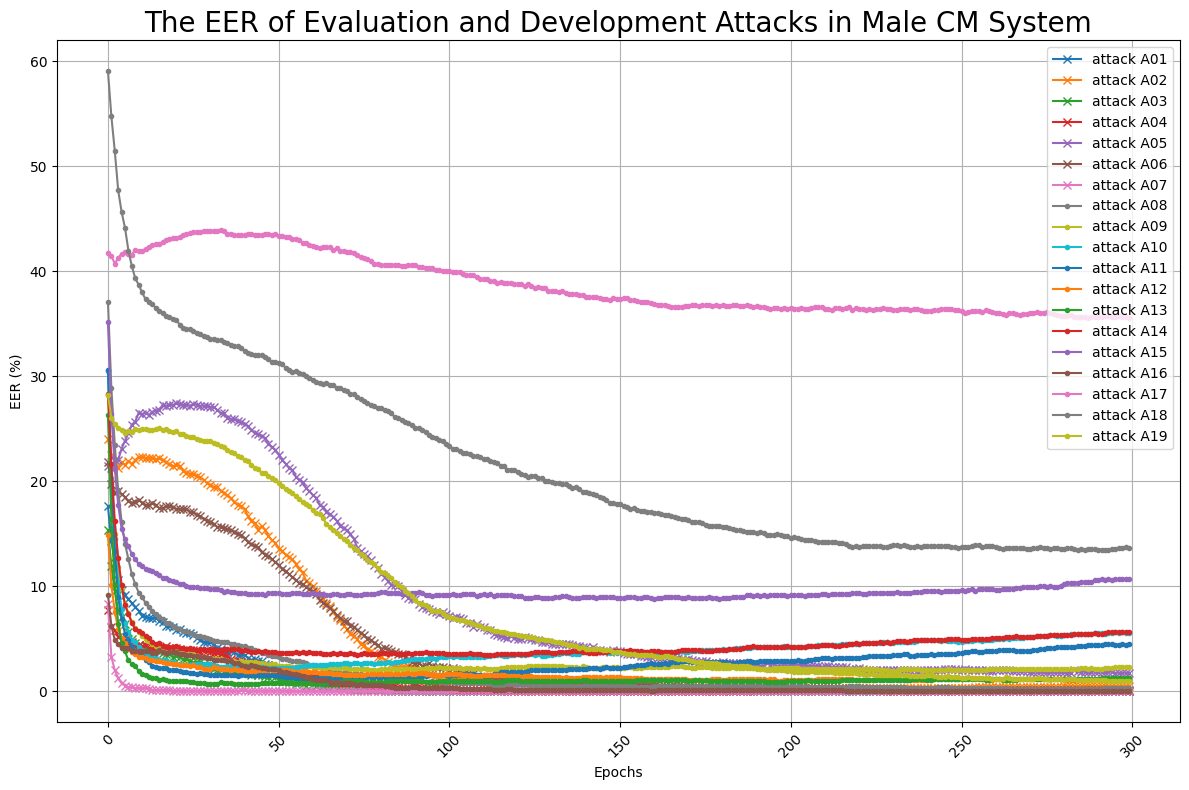

In [22]:
# Number of items in each sublist
data = np.hstack((all_val_list,all_eval_list))
num_items = len(data[0])

# Create a single plot
plt.figure(figsize=(12, 8))

# Plot each item on the same figure with different colors
for i in range(num_items):
    item_values = np.array([sublist[i] for sublist in data])
    if i < 7:
        plt.plot(item_values, marker='x', linestyle='-', label=f'attack A0{i+1}')
    elif  i < 9:
        plt.plot(item_values, marker='.', linestyle='-', label=f'attack A0{i+1}')
    else:
        plt.plot(item_values, marker='.', linestyle='-', label=f'attack A{i+1}')

# Customize the plot
plt.xlabel('Epochs')
plt.ylabel('EER (%)')
#plt.ylim(0, 50)
plt.title('The EER of Evaluation and Development Attacks in Male CM System', fontsize=20)
#plt.title('The EER of Attacks Over Epochs in Female CM Time Embedding System')

#plt.title('EER of Attacks Over Epochs in Female CM Time Embedding System')
plt.legend(loc='upper right')  # Set the legend position to top left
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

# Display the plot
plt.show()

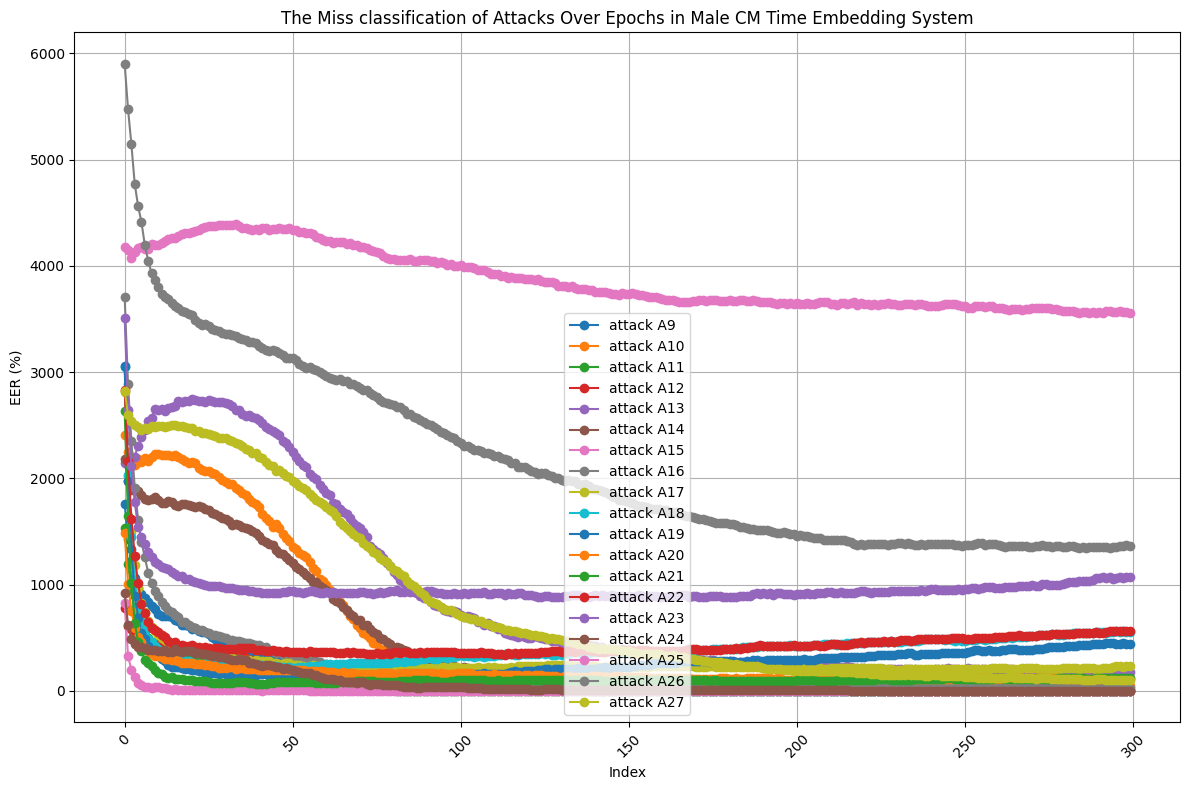

In [23]:
num_items = len(data[0])

# Create a single plot
plt.figure(figsize=(12, 8))

# Plot each item on the same figure with different colors
for i in range(num_items):
    item_values = 100 * np.array([sublist[i] for sublist in data])
    plt.plot(item_values, marker='o', linestyle='-', label=f'attack A{i+9}')

# Customize the plot
plt.xlabel('Index')
plt.ylabel('EER (%)')
#plt.ylim(0, 50)
plt.title('The Miss classification of Attacks Over Epochs in Male CM Time Embedding System')
#plt.title('The EER of Attacks Over Epochs in Female CM Time Embedding System')

#plt.title('EER of Attacks Over Epochs in Female CM Time Embedding System')
plt.legend(loc='lower center')  # Set the legend position to top left
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

# Display the plot
plt.show()

In [24]:
import pickle
#file_path = 'Male_best_model_9_2.pkl'

# Open the file in binary write mode
#with open(file_path, 'wb') as f:
    # Serialize the object and write it to the file
#    pickle.dump(model, f)

In [25]:
import matplotlib.pyplot as plt
# Plot training & validation accuracy and eer values
#DNN_functions.plot_loss_accuracy(num_epoch,train_losses_total,validation_losses_total,train_acc_percentage,validation_acc_percentage,f1_score_validation,validation_total_eer,train_total_err)

## Inference on The Test Set

Here, I will conduct inference to assess the outcomes on the test set. 
Additionally, I will evaluate the model's performance on the test set using metrics such as confusion matrix, Equal Error Rate (EER), and balanced accuracy. 
These assessments will involve utilizing thresholds derived from both the validation set and the test set.

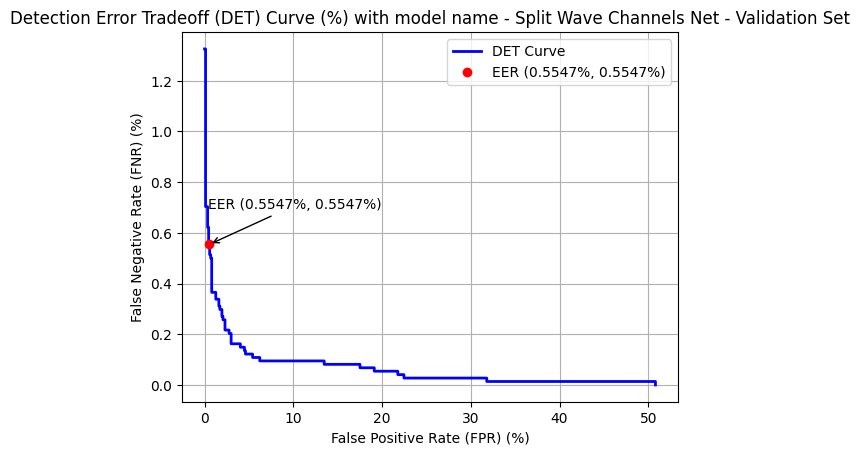

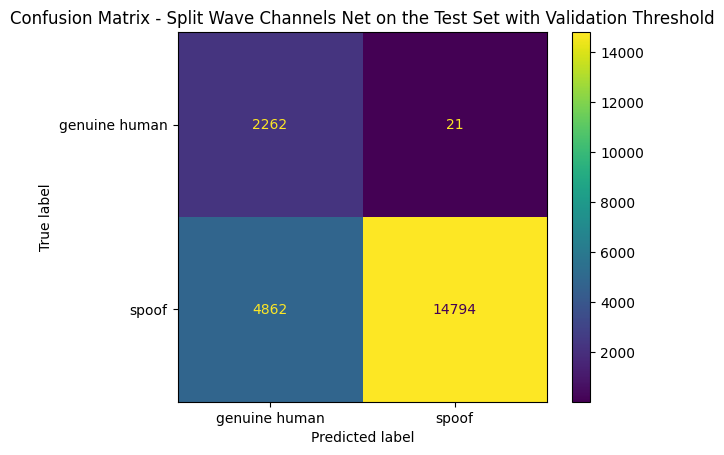

	Test Balanced Accuracy: (0.87172%) 	F1 Score: 0.77743
The validation threshold is:  0.19272867014462294


In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import det_curve
import torch.nn.functional as F 

# get the validation probability
with torch.no_grad():
    if training_type == '1_neorun_end_sigmoid':
        validation_prob = torch.sigmoid(model(torch.Tensor(validation_dataset.data)).cpu())
    
valid_total_prob = validation_prob.cpu().numpy().copy() # copy the validation probability

valid_total_labels = validation_dataset.is_spoofed.copy() # copy the validation labels

eer, val_thresh = my_functions.compute_eer(valid_total_labels,valid_total_prob) # compute equal error rate

fpr, fnr, _ = det_curve(valid_total_labels, valid_total_prob) # compute false positive rate and false negative rate

my_functions.DETCurve(fpr = fpr, fnr = fnr, eer_fpr = eer,eer_fnr = eer, model_name = "Split Wave Channels Net - Validation Set",plot_type="step") # plot DET curve

# get the test probability
with torch.no_grad():
    model = model.to(device)
    if training_type == '1_neorun_end_sigmoid':
        test_prob = torch.sigmoid(model(torch.Tensor(test_dataset.data).to(device)).cpu()) # get the test probability

test_total_prob = test_prob.cpu().numpy().copy() # copy the test probability

test_total_labels = test_dataset.is_spoofed.copy() # copy the test labels


prediction = np.array([1 if total_prob_element > val_thresh else 0 for total_prob_element in test_total_prob]) # get the prediction with the validation threshold

valid_thr_prediction_dnn = prediction.copy() # copy the prediction with the validation threshold

# get the confusion matrix with the validation threshold on the test set
cm = sklearn.metrics.confusion_matrix(test_total_labels, valid_thr_prediction_dnn) 
cm = np.round(cm,2)

# print confusion matrix with the validation threshold on the test set
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                display_labels=["genuine human","spoof"])
disp.plot()
plt.title('Confusion Matrix - Split Wave Channels Net on the Test Set with Validation Threshold')
plt.show()

# Calculate the balanced accuracy for the test set with the validation threshold
balanced_acc= sklearn.metrics.balanced_accuracy_score(test_total_labels,valid_thr_prediction_dnn) # balanced accuracy per batch

# Calculate the f1 score for the test set with the validation threshold
f1_score =sklearn.metrics.f1_score(test_total_labels, valid_thr_prediction_dnn, average='micro') # f1 score  

print(f"\tTest Balanced Accuracy: ({balanced_acc:.5f}%) \tF1 Score: {f1_score:.5f}")
print("The validation threshold is: ",val_thresh)

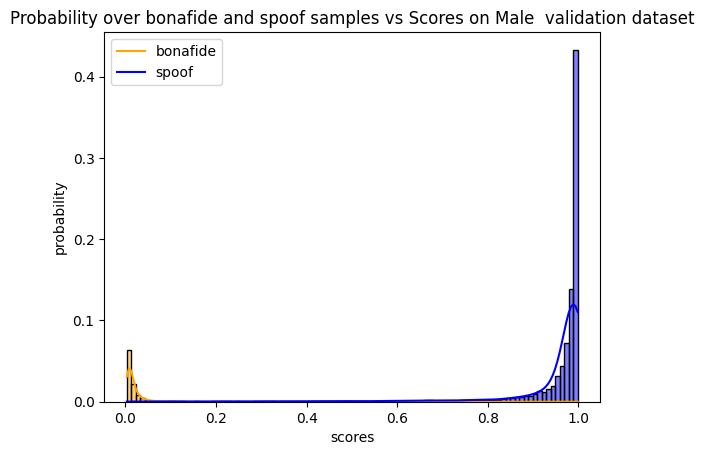

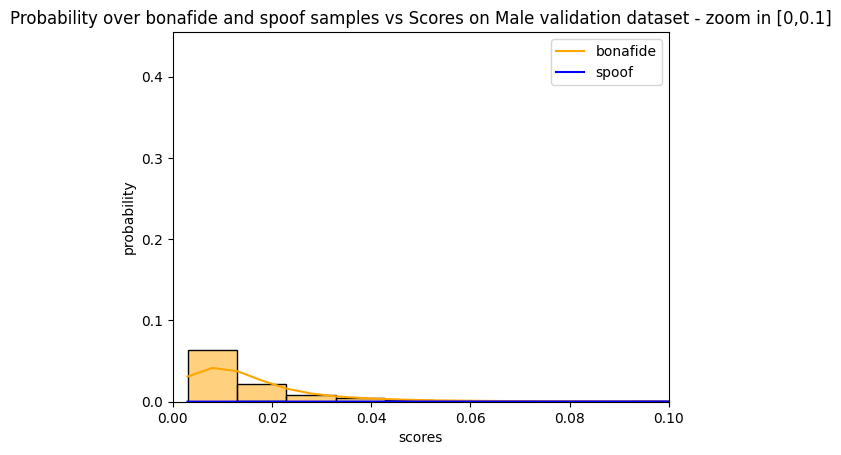

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

bonafide_scores = valid_total_prob[validation_dataset.is_spoofed == 0].flatten()
spoof_scores = valid_total_prob[validation_dataset.is_spoofed == 1].flatten()

num_bins = 100

plt.figure()
sns.histplot([spoof_scores, bonafide_scores], kde=True, stat='probability', bins=num_bins, palette=['blue', 'orange'], linewidth=1)# Add labels and title
plt.legend(['bonafide','spoof'])
plt.xlabel('scores')
plt.ylabel('probability')
plt.title(f"Probability over bonafide and spoof samples vs Scores on Male  validation dataset")
# Add legend
# Show the plot
plt.show()

plt.figure()
sns.histplot([spoof_scores, bonafide_scores], kde=True, stat='probability', bins=num_bins, palette=['blue', 'orange'], linewidth=1)# Add labels and title
plt.legend(['bonafide','spoof'])
plt.xlim(0,0.1)
plt.xlabel('scores')
plt.ylabel('probability')
plt.title(f"Probability over bonafide and spoof samples vs Scores on Male validation dataset - zoom in [0,0.1]")
# Add legend
# Show the plot
plt.show()

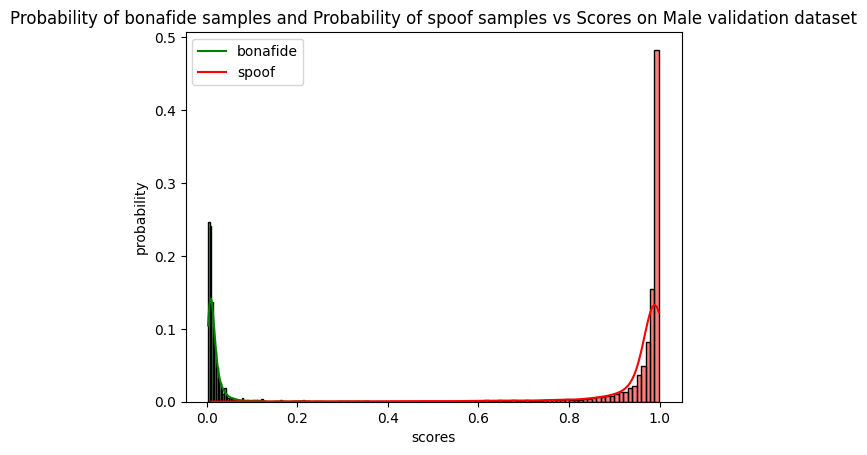

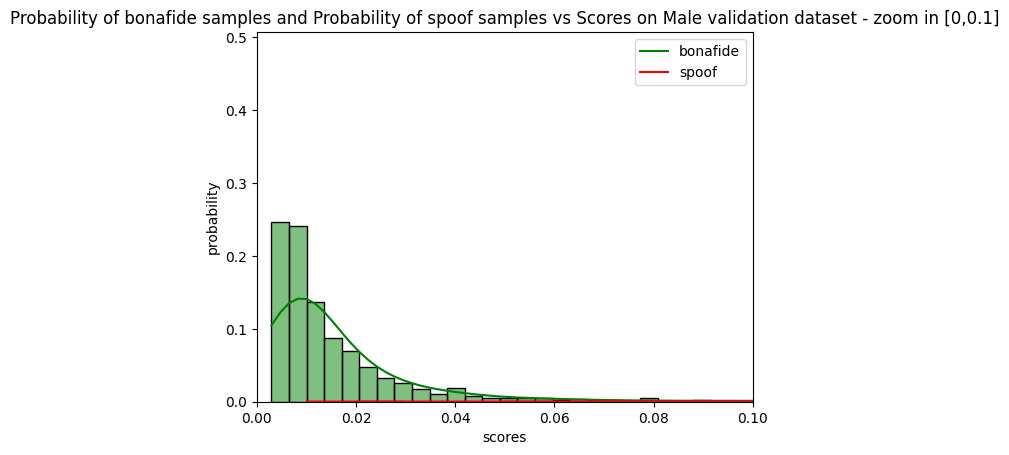

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

bonafide_scores = valid_total_prob[validation_dataset.is_spoofed == 0].flatten()
spoof_scores = valid_total_prob[validation_dataset.is_spoofed == 1].flatten()

num_bins = 100

plt.figure()
sns.histplot(bonafide_scores, kde=True, stat='probability', bins=num_bins, color='green', linewidth=1)# Add labels and title
sns.histplot(spoof_scores, kde=True, stat='probability', bins=num_bins, color='red', linewidth=1)# Add labels and title
plt.legend(['bonafide','spoof'])
plt.xlabel('scores')
plt.ylabel('probability')
plt.title(f"Probability of bonafide samples and Probability of spoof samples vs Scores on Male validation dataset")
# Add legend
# Show the plot
plt.show()

plt.figure()
sns.histplot(bonafide_scores, kde=True, stat='probability', bins=num_bins, color='green', linewidth=1)# Add labels and title
sns.histplot(spoof_scores, kde=True, stat='probability', bins=num_bins, color='red', linewidth=1)# Add labels and title
plt.legend(['bonafide','spoof'])
plt.xlim(0,0.1)
plt.xlabel('scores')
plt.ylabel('probability')
plt.title(f"Probability of bonafide samples and Probability of spoof samples vs Scores on Male validation dataset - zoom in [0,0.1]")
# Add legend
# Show the plot
plt.show()

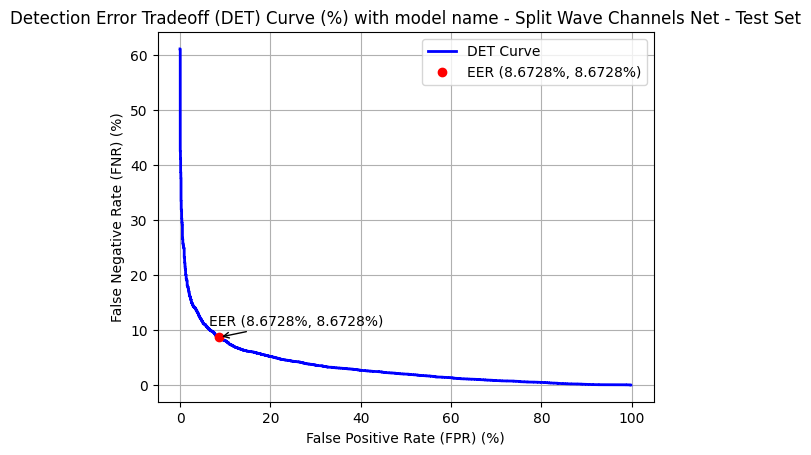

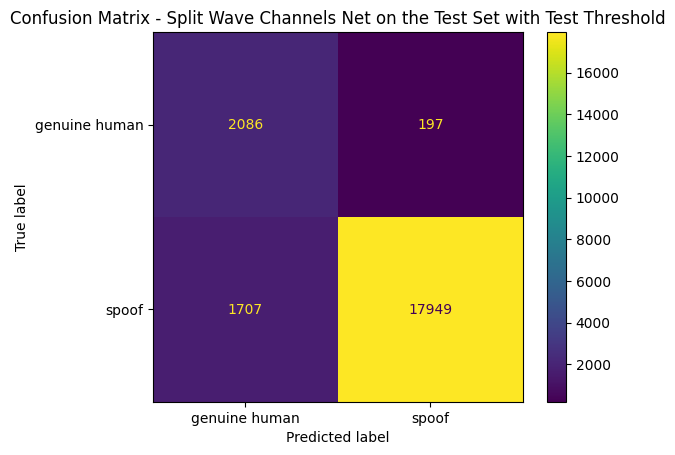

	Test Balanced Accuracy: (0.91343%) 	F1 Score: 0.91321
The test threshold is:  0.04034866020087093


In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import det_curve
import torch.nn.functional as F 
# Calculate the inference on the test set with the test threshold

with torch.no_grad():
    model = model.to(device)
    if training_type == '1_neorun_end_sigmoid': 
        test_prob = torch.sigmoid(model(torch.Tensor(test_dataset.data).to(device)).cpu()) # get the test probability
    
test_total_labels = torch.Tensor(test_dataset.is_spoofed.iloc[:]).cpu().numpy().copy() # copy the test labels

test_total_prob_dnn = test_prob.cpu().numpy().copy() # copy the test probability

eer, test_thresh = my_functions.compute_eer(test_total_labels,test_total_prob_dnn) # compute equal error rate

fpr, fnr, _ = det_curve(test_total_labels, test_total_prob_dnn) # compute false positive rate and false negative rate

my_functions.DETCurve(fpr = fpr, fnr = fnr, eer_fpr = eer,eer_fnr = eer, model_name = "Split Wave Channels Net - Test Set",plot_type="step") # plot DET curve
    
prediction = np.array([1 if total_prob_element > test_thresh else 0 for total_prob_element in test_total_prob_dnn]) # prediction with the test threshold

test_thr_prediction_dnn = prediction.copy() # copy the prediction with the test threshold

cm = sklearn.metrics.confusion_matrix(test_total_labels, test_thr_prediction_dnn) # confusion matrix
cm = np.round(cm,2)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                display_labels=["genuine human","spoof"])
disp.plot()
plt.title('Confusion Matrix - Split Wave Channels Net on the Test Set with Test Threshold')
plt.show()

#Calculate the balanced accuracy for the test set with the test threshold
balanced_acc= sklearn.metrics.balanced_accuracy_score(test_total_labels,test_thr_prediction_dnn) # balanced accuracy per batch

# Calculate the f1 score for the test set with the test threshold
f1_score =sklearn.metrics.f1_score(test_total_labels, test_thr_prediction_dnn, average='micro') # f1 score  
   
print(f"\tTest Balanced Accuracy: ({balanced_acc:.5f}%) \tF1 Score: {f1_score:.5f}")
print("The test threshold is: ",test_thresh)

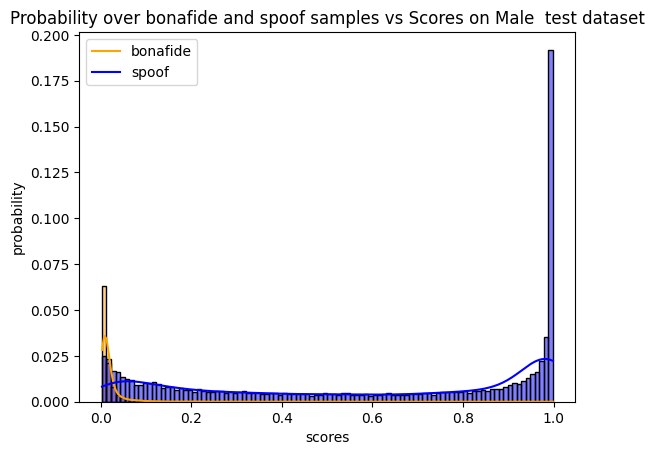

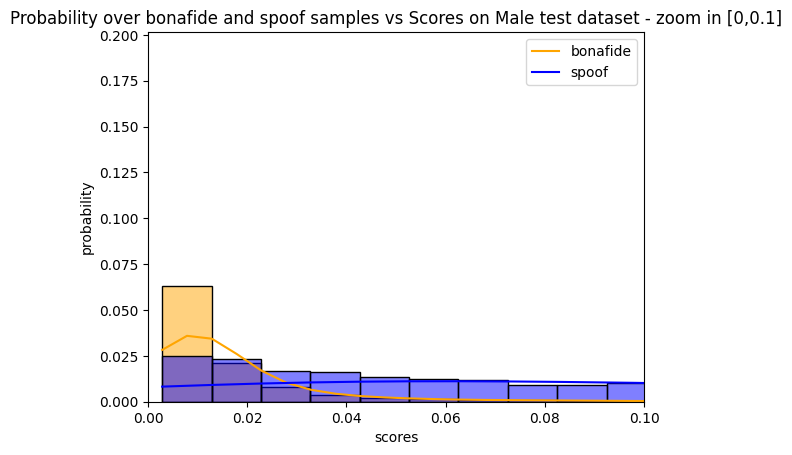

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt


bonafide_scores = test_prob[test_dataset.is_spoofed == 0].flatten()
spoof_scores = test_prob[test_dataset.is_spoofed == 1].flatten()

bonafide_scores = bonafide_scores.cpu().numpy()
spoof_scores = spoof_scores.cpu().numpy()

num_bins = 100

plt.figure()
sns.histplot([spoof_scores, bonafide_scores], kde=True, stat='probability', bins=num_bins, palette=['blue', 'orange'], linewidth=1)# Add labels and title
plt.legend(['bonafide','spoof'])
plt.xlabel('scores')
plt.ylabel('probability')
plt.title(f"Probability over bonafide and spoof samples vs Scores on Male  test dataset")
# Add legend
# Show the plot
plt.show()

plt.figure()
sns.histplot([spoof_scores, bonafide_scores], kde=True, stat='probability', bins=num_bins, palette=['blue', 'orange'], linewidth=1)# Add labels and title
plt.legend(['bonafide','spoof'])
plt.xlim(0,0.1)
plt.xlabel('scores')
plt.ylabel('probability')
plt.title(f"Probability over bonafide and spoof samples vs Scores on Male test dataset - zoom in [0,0.1]")
# Add legend
# Show the plot
plt.show()

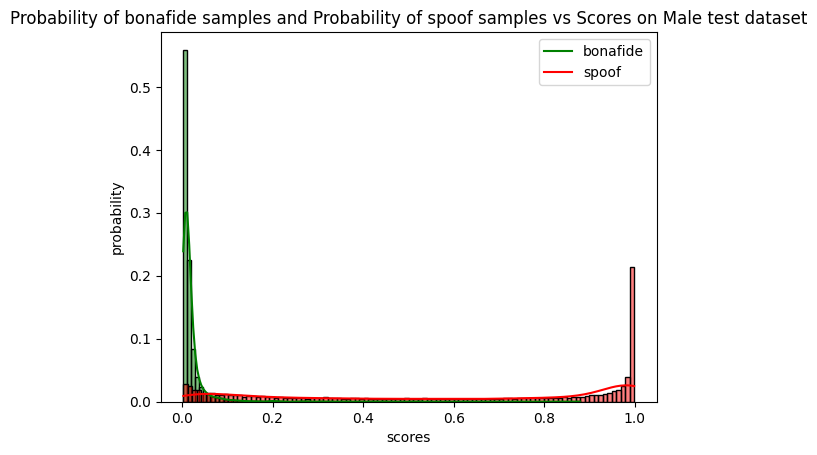

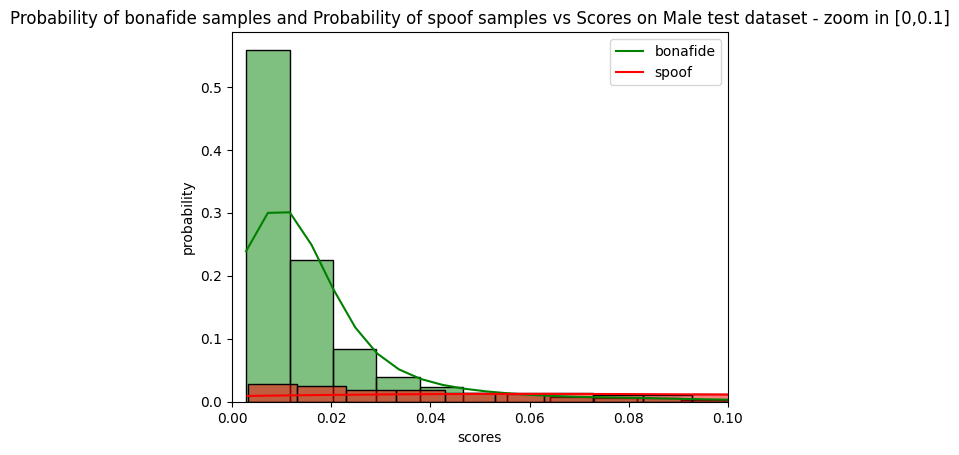

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

bonafide_scores = test_prob[test_dataset.is_spoofed == 0].flatten()
spoof_scores = test_prob[test_dataset.is_spoofed == 1].flatten()

bonafide_scores = bonafide_scores.cpu().numpy()
spoof_scores = spoof_scores.cpu().numpy()


num_bins = 100

plt.figure()
sns.histplot(bonafide_scores, kde=True, stat='probability', bins=num_bins, color='green', linewidth=1)# Add labels and title
sns.histplot(spoof_scores, kde=True, stat='probability', bins=num_bins, color='red', linewidth=1)# Add labels and title
plt.legend(['bonafide','spoof'])
plt.xlabel('scores')
plt.ylabel('probability')
plt.title(f"Probability of bonafide samples and Probability of spoof samples vs Scores on Male test dataset")
# Add legend
# Show the plot
plt.show()

plt.figure()
sns.histplot(bonafide_scores, kde=True, stat='probability', bins=num_bins, color='green', linewidth=1)# Add labels and title
sns.histplot(spoof_scores, kde=True, stat='probability', bins=num_bins, color='red', linewidth=1)# Add labels and title
plt.legend(['bonafide','spoof'])
plt.xlim(0,0.1)
plt.xlabel('scores')
plt.ylabel('probability')
plt.title(f"Probability of bonafide samples and Probability of spoof samples vs Scores on Male test dataset - zoom in [0,0.1]")
# Add legend
# Show the plot
plt.show()

In [32]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import classification_report,accuracy_score
from sklearn.metrics import balanced_accuracy_score


pred_proba_list = [test_total_prob_dnn] # list of the test probability
y_pred = [test_thr_prediction_dnn] # list of the test prediction

test_total_labels = [test_dataset.is_spoofed.iloc[:].astype('uint8')] # list of the test labels

eer_list = []
acc_list = []
balanced_acc_list = []
auc_list = []
f1_list = [] 
# calculate the metrics for the test set with the test threshold
for i in range(0,len(pred_proba_list)): #
     eer , _ = my_functions.compute_eer(test_total_labels[i],pred_proba_list[i])
     eer_list.append(eer)
     acc_list.append(accuracy_score(test_total_labels[i], y_pred[i]))
     balanced_acc_list.append(balanced_accuracy_score(test_total_labels[i], y_pred[i]))
     auc_list.append(roc_auc_score(test_total_labels[i],pred_proba_list[i]))
     f1_list.append(sklearn.metrics.f1_score(test_total_labels[i], y_pred[i]))
  
     
y_pred_with_valid_thr = [valid_thr_prediction_dnn] 

validation_pos_pred_proba_list = [valid_total_prob]    

valid_total_labels = [validation_dataset.is_spoofed.iloc[:].astype('uint8')]


eer_list_on_validaion = []
acc_list_with_valid_thr = []
balanced_acc_list_with_valid_thr = []
f1_list_with_valid_thr = []
# calculate the metrics for the test set with the validation threshold
for i in range(0,len(validation_pos_pred_proba_list)): 
     acc_list_with_valid_thr.append(accuracy_score(test_total_labels[i], y_pred_with_valid_thr[i]))
     balanced_acc_list_with_valid_thr.append(balanced_accuracy_score(test_total_labels[i], y_pred_with_valid_thr[i]))
     f1_list_with_valid_thr.append(sklearn.metrics.f1_score(test_total_labels[i], y_pred_with_valid_thr[i]))
     eer_val , _ = my_functions.compute_eer(valid_total_labels[i],validation_pos_pred_proba_list[i])
     eer_list_on_validaion.append(eer_val)

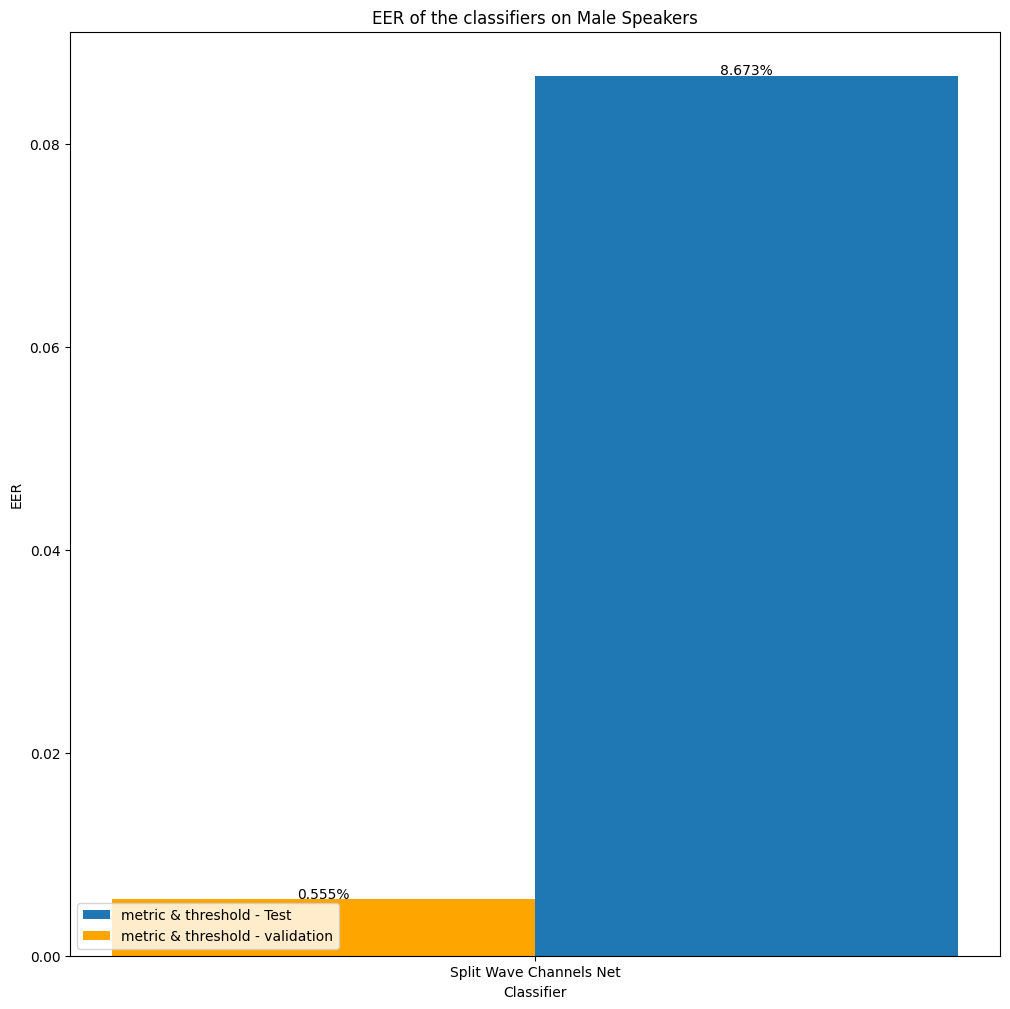

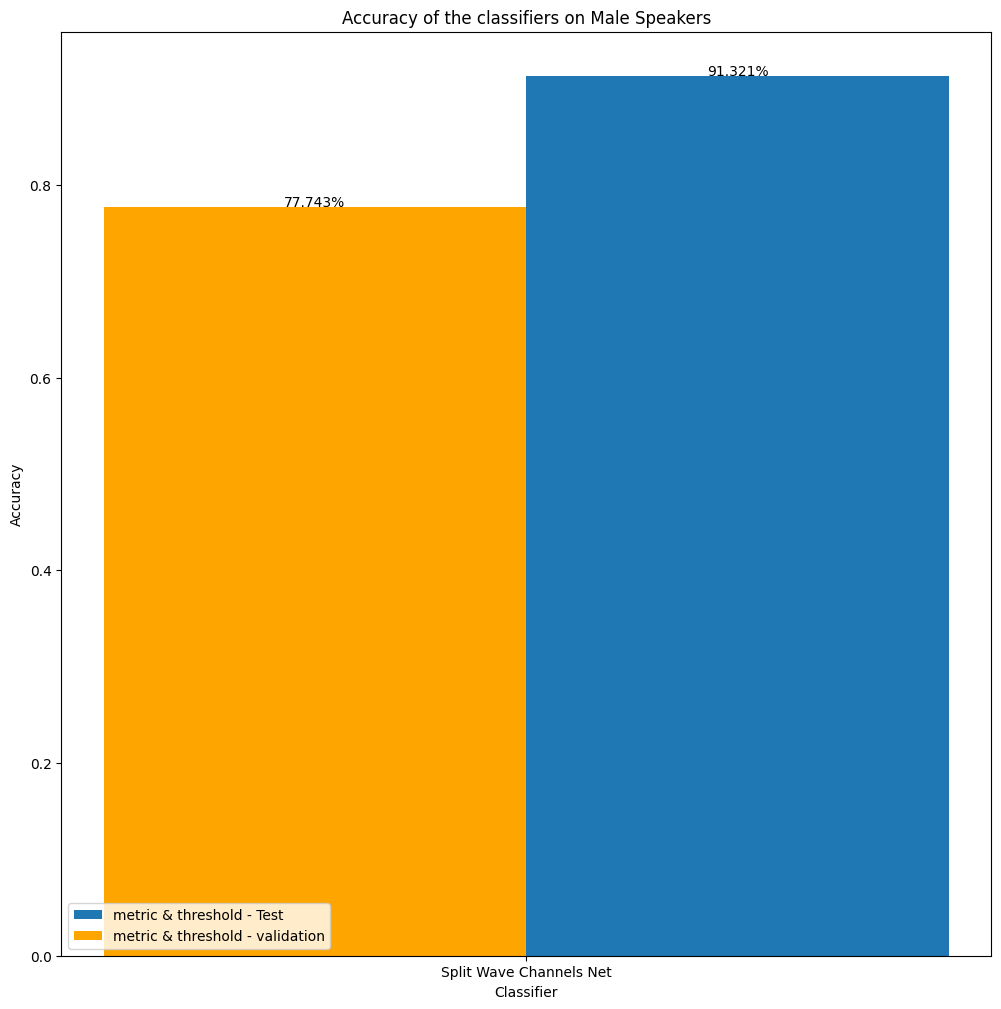

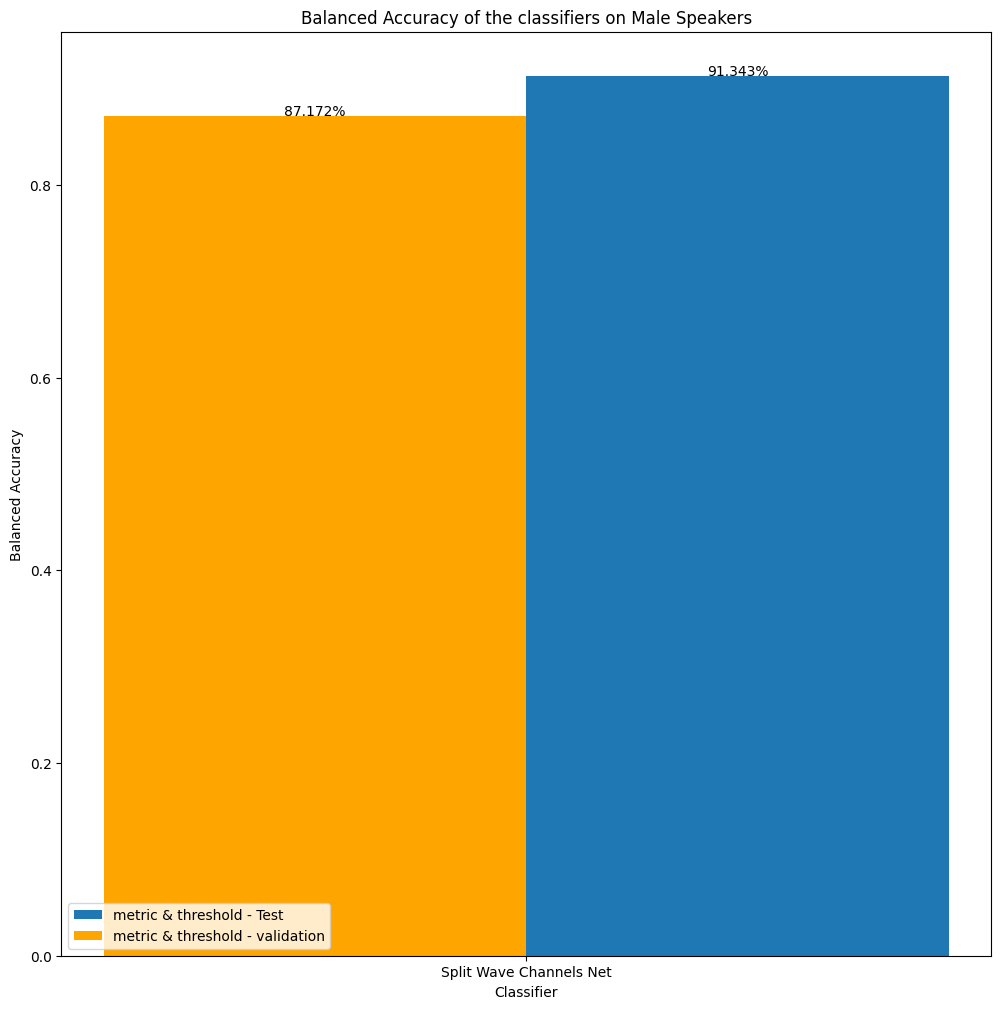

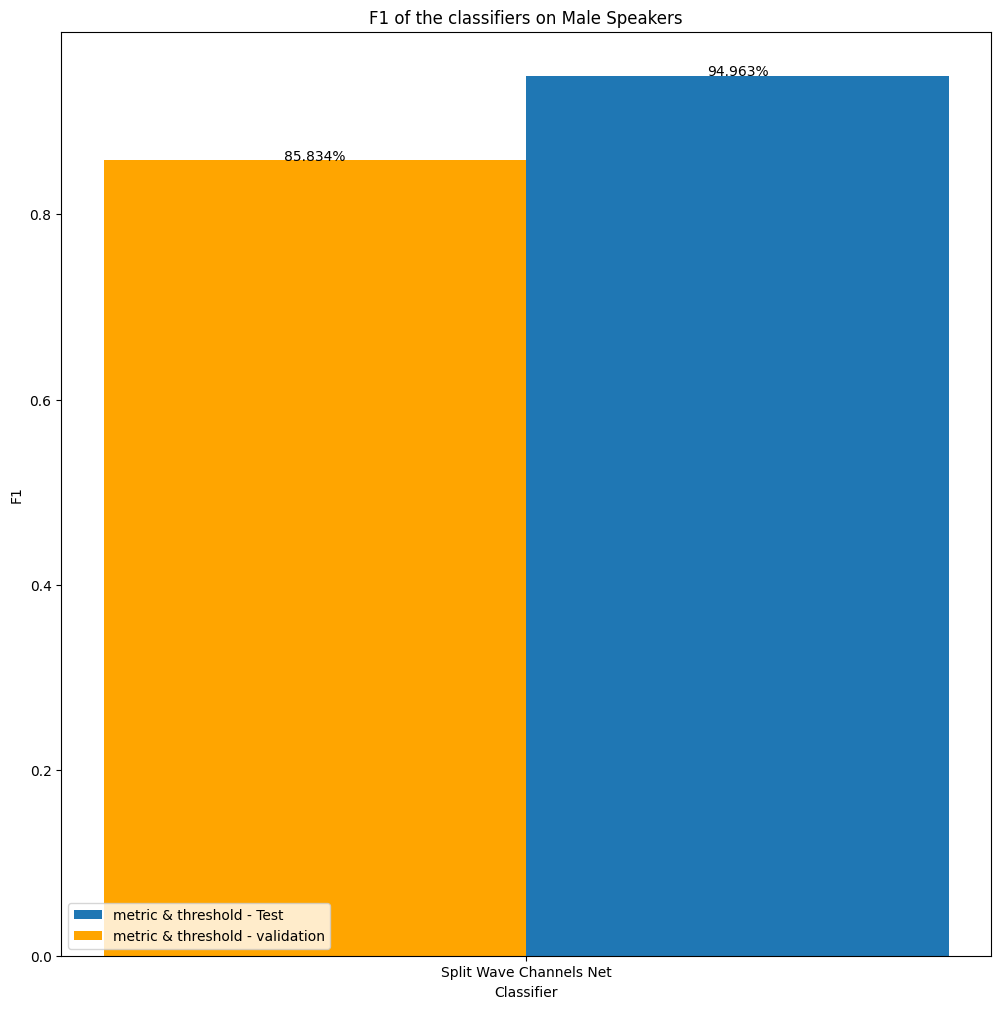

<Figure size 1200x1200 with 0 Axes>

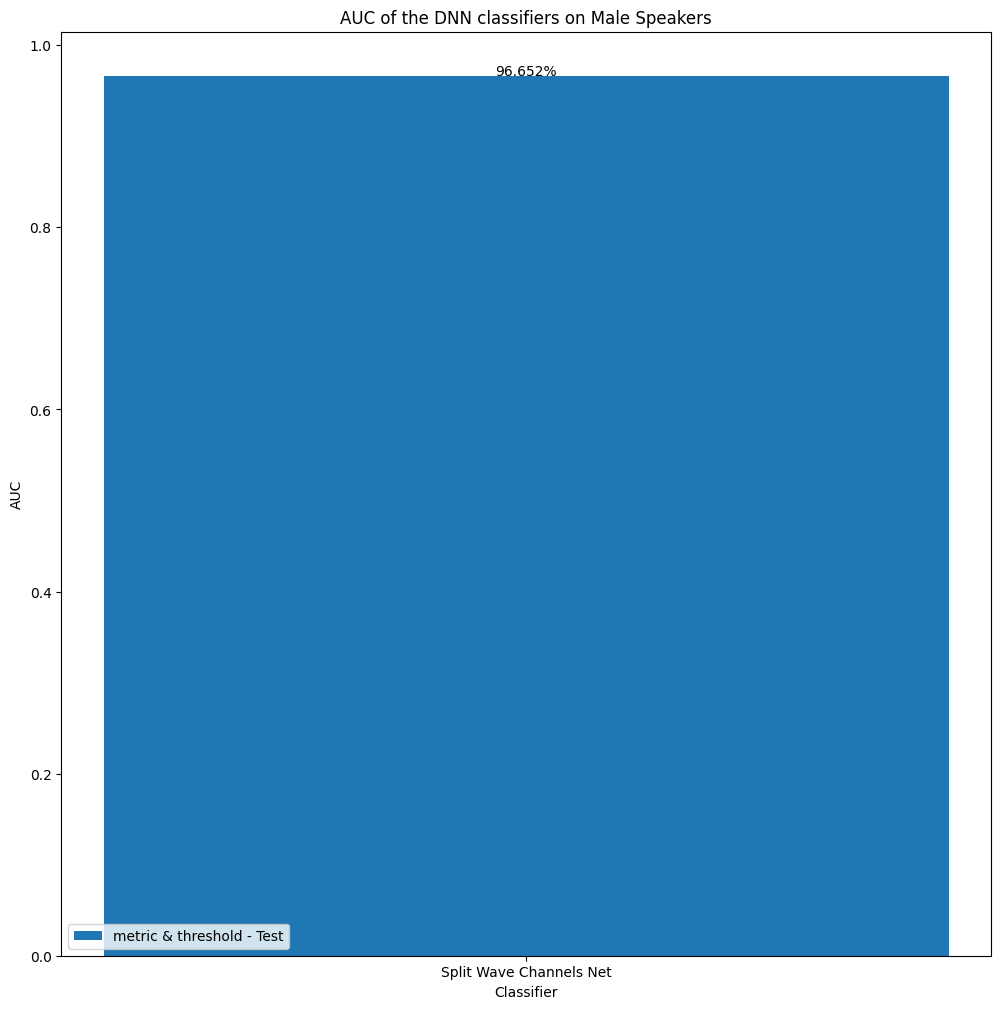

In [33]:
# define the names of the classifiers
names = ['Split Wave Channels Net']
metric_names = ['EER','Accuracy','Balanced Accuracy','F1','AUC']

#plot hisgogram of the results: EER, Accuracy, Balanced Accuracy, AUC
metrics_list = [eer_list,acc_list,balanced_acc_list,f1_list,auc_list] # list of the test metrics
validaion_metrics_list = [eer_list_on_validaion,acc_list_with_valid_thr,balanced_acc_list_with_valid_thr,f1_list_with_valid_thr] # list of the validation metrics

# define the diff for the bar names
diff_for_bar = 0.0001
X_axis = np.arange(len(names))

#Plot the results   
for i in range(0,len(validaion_metrics_list)):
    plt.figure(figsize=(12,12))
    plt.bar(X_axis+0.2, metrics_list[i],width=0.4,label = 'metric & threshold - Test')
    plt.bar(X_axis-0.2, validaion_metrics_list[i],width=0.4,label = 'metric & threshold - validation',color='orange')
    plt.ylabel(metric_names[i])
    plt.xlabel('Classifier')
    plt.title(f"{metric_names[i]} of the classifiers on Male Speakers")
    plt.legend(loc = 'lower left')
    plt.xticks(X_axis, names)
    for j, v in enumerate(metrics_list[i]):
        plt.text(j+0.2, v+diff_for_bar, '{:.3f}%'.format(v*100), ha='center')
    for j, v in enumerate(validaion_metrics_list[i]):
        plt.text(j-0.2, v+diff_for_bar, '{:.3f}%'.format(v*100), ha='center')
    plt.show()
    
plt.figure(figsize=(12,12))

i = len(validaion_metrics_list)   

#plot hisgogram of the results: AUC
plt.figure(figsize=(12,12))
plt.bar(X_axis, metrics_list[i],width=0.4,label = 'metric & threshold - Test')
plt.ylabel(metric_names[i])
plt.xlabel('Classifier')
plt.title(f"{metric_names[i]} of the DNN classifiers on Male Speakers")
plt.legend(loc = 'lower left')
plt.xticks(X_axis, names)
for j, v in enumerate(metrics_list[i]):
        plt.text(j, v+diff_for_bar, '{:.3f}%'.format(v*100), ha='center')   
plt.show()


In [34]:
'''
import pickle

filename = 'male_model_8.83.pkl'
pickle.dump(model, open(filename, 'wb'))
torch.save(model.state_dict(), 'male_model_8.83.pth')
'''

"\nimport pickle\n\nfilename = 'male_model_8.83.pkl'\npickle.dump(model, open(filename, 'wb'))\ntorch.save(model.state_dict(), 'male_model_8.83.pth')\n"